# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [10]:
df = pd.read_csv(r"C:\Users\samco\OneDrive\LP\Repositorios DEV\EBAC_Estudos\EBAC\Estatistica\MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [ ]:
#Seu código aqui para a média

df['Preco_Normal'].mean()

np.float64(2070.9972899728996)

In [12]:
#Seu código aqui para a mediana
df['Preco_Normal'].median()

np.float64(1269.0)

Digite aqui as categorias:

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [21]:
#Seu código aqui
print('DESVIO PADRÃO POR CATEGORIA: \n',df.groupby('Categoria')['Preco_Normal'].std().reset_index())

print('MÉDIA POR CATEGORIA: \n',df.groupby('Categoria')['Preco_Normal'].mean().reset_index())

print('MEDIANA POR CATEGORIA: \n',df.groupby('Categoria')['Preco_Normal'].median().reset_index())

DESVIO PADRÃO POR CATEGORIA: 
                     Categoria  Preco_Normal
0  belleza-y-cuidado-personal   2210.041719
1          comidas-preparadas   2019.911428
2                  congelados   2111.539896
3                      frutas   1639.151114
4        instantaneos-y-sopas   1170.232869
5                     lacteos   3925.816164
6                    verduras   1012.699625
MÉDIA POR CATEGORIA: 
                     Categoria  Preco_Normal
0  belleza-y-cuidado-personal   1783.556485
1          comidas-preparadas   3095.043478
2                  congelados   2108.042553
3                      frutas   1724.473684
4        instantaneos-y-sopas    765.491228
5                     lacteos   2385.219239
6                    verduras   1343.296875
MEDIANA POR CATEGORIA: 
                     Categoria  Preco_Normal
0  belleza-y-cuidado-personal        1569.0
1          comidas-preparadas        3290.0
2                  congelados        1519.0
3                      frutas        1195

Digite nesse campo o comportamento que você identificou.

As categorias com mais desvio padrão apresentam um valor, tanto da média quanto da mediana, muito longe do que é a média e a mediana de todos os produtos podendo haver nelas muitos valores de produtos considerados outliers

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

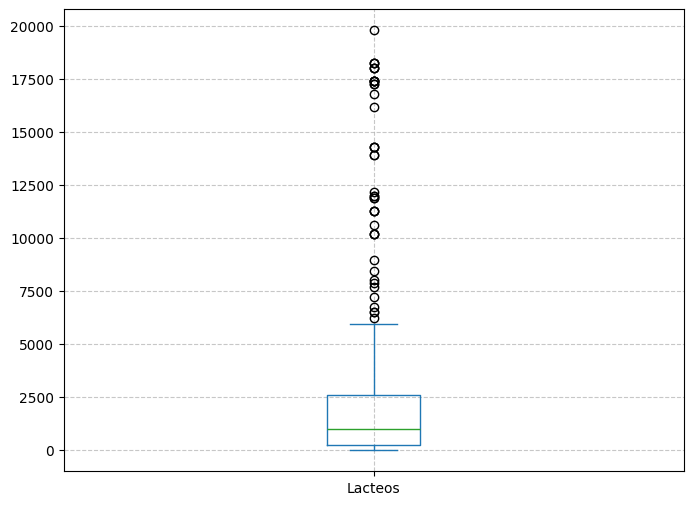

In [48]:
#Seu código aqui


plt.figure(figsize=(8, 6))
df.loc[df['Categoria'] == 'lacteos']['Preco_Normal'].plot(kind='box',label='Lacteos')
plt.grid(True, linestyle='--', alpha=0.7)




O gráfico mostra muitos outliers que acabam elevando a média da categoria e a média geral do valor dos produtos. Essa categoria está cheia de produtos que 'enganam' as métricas

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

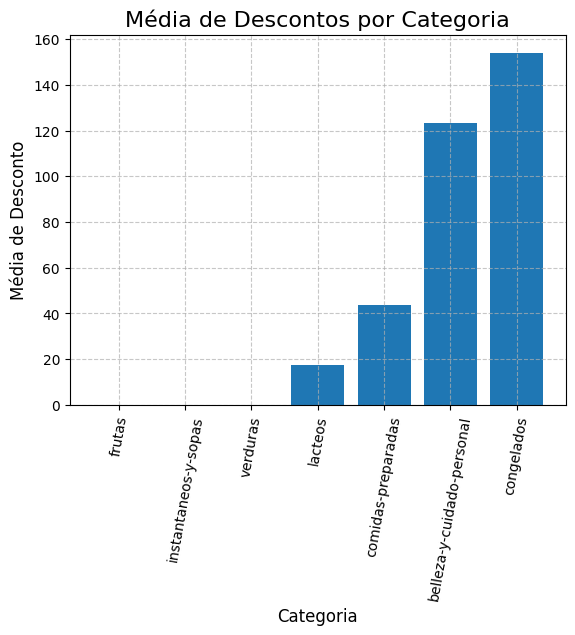

In [47]:
# Seu código aqui
descontos_por_categoria = df.groupby('Categoria')['Desconto'].mean().sort_values()
plt.bar(descontos_por_categoria.index, descontos_por_categoria)
plt.title('Média de Descontos por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Média de Desconto', fontsize=12)
plt.xticks(rotation=80)
plt.grid(True, linestyle='--', alpha=0.7)

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [49]:
# Seu código aqui

descontos_por_categoria_marca = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index() 
fig = px.treemap(descontos_por_categoria_marca, 
                 path=['Categoria', 'Marca'], 
                 values='Desconto', 
                 title='Descontos por categoria e marca', 
                 color='Marca')
fig.show()
